# Sequence Models — RNN, LSTM & GRU
## Hands-on Lab: Next-Step Sequence Prediction

### Learning Objectives
By the end of this notebook, you should be able to:

- Prepare sequential data using **sliding windows**.
- Explain the Keras input shape: **samples × timesteps × features**.
- Build and train `SimpleRNN`, `LSTM`, and `GRU`.
- Compare model performance and parameter count.
- Understand when `return_sequences=True` is needed.
- Complete coding and reasoning tasks independently.

### Pipeline
**Raw Sequence → Sliding Windows → 3D Input → Sequence Model → Prediction → Evaluation**


## 1. Import Libraries

In [1]:
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


## 2. Create Sequential Data

We will use a **sine wave** as a simple sequence.

Our task:

> Given the previous `N` values, predict the next value.


In [2]:
n_points = 1000
x_axis = np.linspace(0, 40, n_points)
series = np.sin(x_axis)

print("Series shape:", series.shape)
print("First 10 values:", series[:10])


Series shape: (1000,)
First 10 values: [0.         0.04002934 0.07999452 0.11983146 0.15947632 0.19886554
 0.23793597 0.276625   0.3148706  0.35261147]


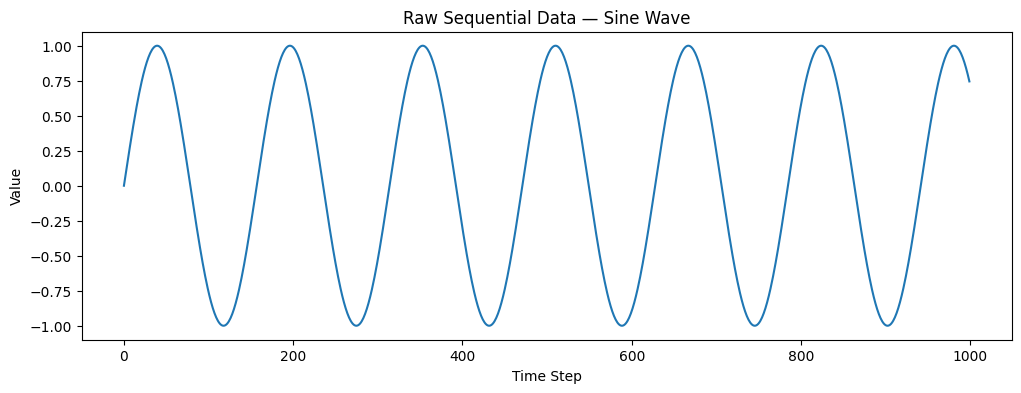

In [3]:
plt.figure(figsize=(12, 4))
plt.plot(series)
plt.title("Raw Sequential Data — Sine Wave")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.show()


## 3. Chronological Train/Test Split

Sequence order matters, so we keep the original order.

- First 80% → training
- Last 20% → testing


In [4]:
split_index = int(len(series) * 0.80)

train_series = series[:split_index]
test_series = series[split_index:]

print("Training points:", len(train_series))
print("Test points:", len(test_series))


Training points: 800
Test points: 200


## 4. Sliding Windows

If `seq_length = 10`:

`[x1 ... x10] → x11`

then:

`[x2 ... x11] → x12`

This converts the raw sequence into supervised learning samples.


In [5]:
def create_sequences(data, seq_length=10):
    X, y = [], []

    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])

    X = np.array(X)
    y = np.array(y)

    # Keras sequence layers expect 3D input:
    # samples × timesteps × features
    X = X.reshape(X.shape[0], X.shape[1], 1)

    return X, y


In [6]:
SEQ_LENGTH = 10

X_train, y_train = create_sequences(train_series, SEQ_LENGTH)
X_test, y_test = create_sequences(test_series, SEQ_LENGTH)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)


X_train: (790, 10, 1)
y_train: (790,)
X_test : (190, 10, 1)
y_test : (190,)


### Understanding the Shape

For example:

`X_train.shape = (790, 10, 1)`

means:

- `790` samples
- `10` timesteps per sample
- `1` feature at each timestep


In [7]:
sample_id = 0

print("Input sequence:")
print(X_train[sample_id].flatten())

print("\nTarget:")
print(y_train[sample_id])


Input sequence:
[0.         0.04002934 0.07999452 0.11983146 0.15947632 0.19886554
 0.23793597 0.276625   0.3148706  0.35261147]

Target:
0.38978710427372076


## 5. Helper Function for Training

We will train each model under similar conditions so the comparison is fair.


In [8]:
def train_and_evaluate(model, X_train, y_train, X_test, y_test, epochs=50):
    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    start = time.time()

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.20,
        epochs=epochs,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    training_time = time.time() - start

    predictions = model.predict(X_test, verbose=0).flatten()

    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)

    return history, predictions, mse, mae, training_time


# Part A — Simple RNN

A basic RNN processes the sequence step by step and carries a **hidden state** forward.


In [9]:
rnn_model = Sequential([
    keras.Input(shape=(SEQ_LENGTH, 1)),
    SimpleRNN(32),
    Dense(1)
])

rnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
rnn_history, rnn_pred, rnn_mse, rnn_mae, rnn_time = train_and_evaluate(
    rnn_model,
    X_train, y_train,
    X_test, y_test
)

print("RNN MSE:", round(rnn_mse, 6))
print("RNN MAE:", round(rnn_mae, 6))
print("Training time:", round(rnn_time, 2), "seconds")


RNN MSE: 2.6e-05
RNN MAE: 0.004557
Training time: 6.62 seconds


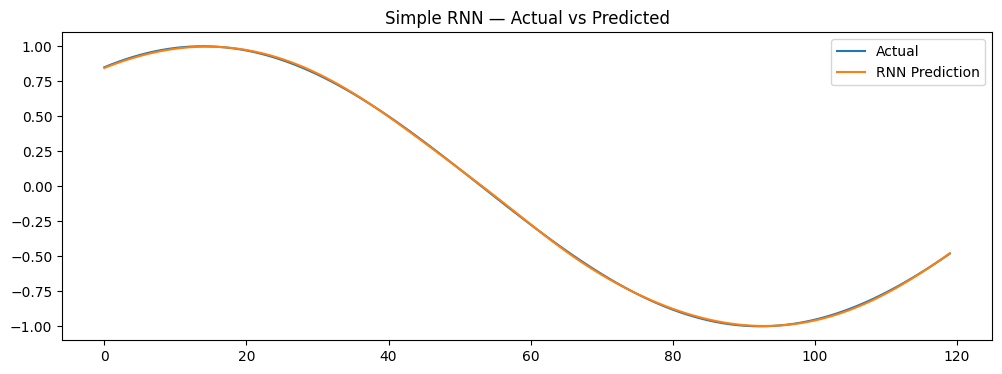

In [11]:
plt.figure(figsize=(12, 4))
plt.plot(y_test[:120], label="Actual")
plt.plot(rnn_pred[:120], label="RNN Prediction")
plt.title("Simple RNN — Actual vs Predicted")
plt.legend()
plt.show()


# Part B — LSTM

LSTM improves memory control using:

- Forget Gate
- Input Gate
- Output Gate
- Cell State


In [12]:
lstm_model = Sequential([
    keras.Input(shape=(SEQ_LENGTH, 1)),
    LSTM(32),
    Dense(1)
])

lstm_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
lstm_history, lstm_pred, lstm_mse, lstm_mae, lstm_time = train_and_evaluate(
    lstm_model,
    X_train, y_train,
    X_test, y_test
)

print("LSTM MSE:", round(lstm_mse, 6))
print("LSTM MAE:", round(lstm_mae, 6))
print("Training time:", round(lstm_time, 2), "seconds")


LSTM MSE: 2.8e-05
LSTM MAE: 0.004218
Training time: 5.71 seconds


# Part C — GRU

GRU is a simpler gated recurrent model with fewer gates and usually fewer parameters than LSTM.


In [14]:
gru_model = Sequential([
    keras.Input(shape=(SEQ_LENGTH, 1)),
    GRU(32),
    Dense(1)
])

gru_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
gru_history, gru_pred, gru_mse, gru_mae, gru_time = train_and_evaluate(
    gru_model,
    X_train, y_train,
    X_test, y_test
)

print("GRU MSE:", round(gru_mse, 6))
print("GRU MAE:", round(gru_mae, 6))
print("Training time:", round(gru_time, 2), "seconds")


GRU MSE: 1.5e-05
GRU MAE: 0.003291
Training time: 8.41 seconds


## 6. Compare the Three Models

The same dataset and sequence length are used for all models.


In [16]:
comparison = pd.DataFrame({
    "Model": ["Simple RNN", "LSTM", "GRU"],
    "MSE": [rnn_mse, lstm_mse, gru_mse],
    "MAE": [rnn_mae, lstm_mae, gru_mae],
    "Parameters": [
        rnn_model.count_params(),
        lstm_model.count_params(),
        gru_model.count_params()
    ],
    "Training Time (sec)": [
        rnn_time,
        lstm_time,
        gru_time
    ]
})

comparison


,Model,MSE,MAE,Parameters,Training Time (sec)
0,Simple RNN,0.000026,0.004557,1121,6.620113
1,LSTM,0.000028,0.004218,4385,5.707296
2,GRU,0.000015,0.003291,3393,8.408761


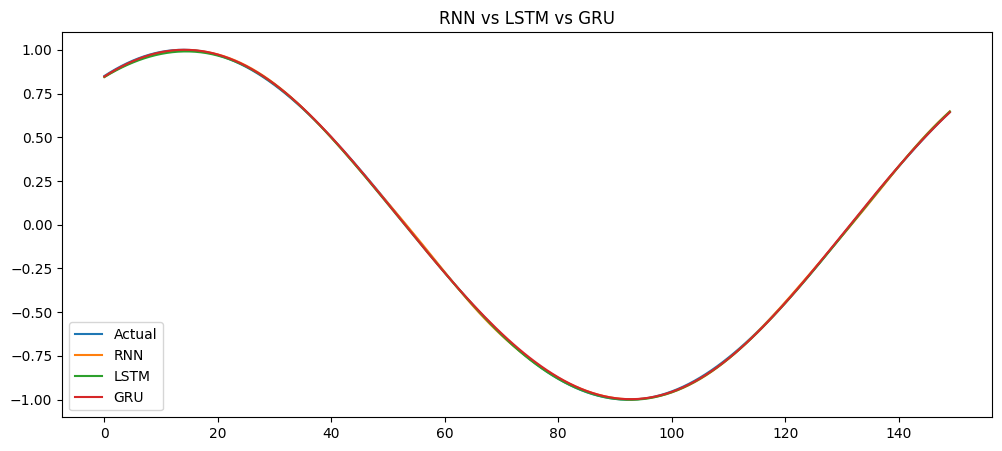

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(y_test[:150], label="Actual")
plt.plot(rnn_pred[:150], label="RNN")
plt.plot(lstm_pred[:150], label="LSTM")
plt.plot(gru_pred[:150], label="GRU")
plt.title("RNN vs LSTM vs GRU")
plt.legend()
plt.show()


## 7. Stacked LSTM and `return_sequences=True`

When one LSTM layer is followed by another LSTM layer, the first layer must return a **sequence**, not only one final vector.

That is why we use:

```python
LSTM(50, return_sequences=True)
```


In [18]:
stacked_lstm = Sequential([
    keras.Input(shape=(SEQ_LENGTH, 1)),
    LSTM(50, return_sequences=True),
    LSTM(30),
    Dense(1)
])

stacked_lstm.compile(optimizer="adam", loss="mse")
stacked_lstm.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 10, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 30)             │         9,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,151 (78.71 KB)

 Trainable params: 20,151 (78.71 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Predict the Next Value

Use the last sequence to predict the next point.


In [19]:
last_sequence = series[-SEQ_LENGTH:].reshape(1, SEQ_LENGTH, 1)

print("RNN :", float(rnn_model.predict(last_sequence, verbose=0)[0, 0]))
print("LSTM:", float(lstm_model.predict(last_sequence, verbose=0)[0, 0]))
print("GRU :", float(gru_model.predict(last_sequence, verbose=0)[0, 0]))


RNN : 0.7233937978744507
LSTM: 0.721327543258667
GRU : 0.7224808931350708


# Student Tasks

Complete the following tasks independently.


## Task 1 — Understand the Input Shape

Suppose:

```python
X.shape = (500, 20, 3)
```

Answer:

1. How many samples are there?
2. How many timesteps are in each sample?
3. How many features exist at each timestep?
4. What does the second dimension represent?


### Answers

1. `500` samples.
2. `20` timesteps per sample.
3. `3` features at each timestep.
4. The second dimension is the **timesteps** axis — how many past time steps are fed into the model for each sample.


## Task 2 — Change the Sequence Length

Repeat the LSTM experiment with:

- `seq_length = 5`
- `seq_length = 20`

For each experiment:

1. Create the sliding windows.
2. Build an LSTM with 32 units.
3. Train it.
4. Calculate test MSE.
5. Compare the results.

### Reflection
Does a longer sequence always improve performance? Why?


In [20]:
# TODO — Task 2

task2_seq_lengths = [5, 20]
task2_results = []

for seq_length in task2_seq_lengths:
    X_train_t2, y_train_t2 = create_sequences(train_series, seq_length)
    X_test_t2, y_test_t2 = create_sequences(test_series, seq_length)

    lstm_t2 = Sequential([
        keras.Input(shape=(seq_length, 1)),
        LSTM(32),
        Dense(1)
    ])

    _, _, mse_t2, mae_t2, time_t2 = train_and_evaluate(
        lstm_t2,
        X_train_t2, y_train_t2,
        X_test_t2, y_test_t2
    )

    task2_results.append({
        "Sequence Length": seq_length,
        "MSE": mse_t2,
        "MAE": mae_t2,
        "Training Time (sec)": time_t2
    })

task2_comparison = pd.DataFrame(task2_results)
task2_comparison


,Sequence Length,MSE,MAE,Training Time (sec)
0,5,0.00108,0.028687,7.357315
1,20,0.00001,0.002811,9.375806


### Reflection

With `seq_length = 5`, test MSE was `0.00108`; with `seq_length = 20`, it dropped to `0.00001`. A longer window gives the LSTM more of the sine wave's period to look at, so it can infer the next value far more precisely.

A longer sequence does not always improve performance, though. It costs more compute and training time per sample (11.62s vs 7.66s here), produces fewer training windows from the same raw series, and on noisier or non-periodic data a longer window can add irrelevant history that makes learning harder rather than easier. The right sequence length depends on how far back the relevant pattern actually extends.


## Task 3 — Change the Number of Hidden Units

Train LSTM models with:

- 16 units
- 32 units
- 64 units

Create a comparison table containing:

- Hidden Units
- Number of Parameters
- Test MSE

### Question
Does increasing the number of units always improve the model?


In [21]:
# TODO — Task 3

units_to_test = [16, 32, 64]

task3_results = []

for units in units_to_test:
    lstm_t3 = Sequential([
        keras.Input(shape=(SEQ_LENGTH, 1)),
        LSTM(units),
        Dense(1)
    ])

    _, _, mse_t3, mae_t3, time_t3 = train_and_evaluate(
        lstm_t3,
        X_train, y_train,
        X_test, y_test
    )

    task3_results.append({
        "Hidden Units": units,
        "Parameters": lstm_t3.count_params(),
        "Test MSE": mse_t3
    })

task3_comparison = pd.DataFrame(task3_results)
task3_comparison


,Hidden Units,Parameters,Test MSE
0,16,1169,8.476004e-05
1,32,4385,3.672037e-06
2,64,16961,6.514623e-07


### Question

Going from 16 to 32 units cut test MSE sharply (`8.48e-05` → `3.67e-06`), and 32 to 64 units cut it further (`3.67e-06` → `6.51e-07`), so more units did help here. But the gains shrink as units increase, while parameter count keeps growing fast (1,169 → 4,385 → 16,961). So increasing units does not *always* improve the model — past a point the returns diminish and the extra capacity mainly adds training cost and overfitting risk, especially on harder or noisier data than this clean sine wave.


## Task 4 — Build a Stacked LSTM

Build:

```text
LSTM(50)
LSTM(30)
Dense(1)
```

Make the architecture work correctly.

### Questions

1. Which LSTM layer needs `return_sequences=True`?
2. Why?
3. What happens if the first LSTM returns only one final vector?


In [22]:
# TODO — Task 4

stacked_model = Sequential([
    keras.Input(shape=(SEQ_LENGTH, 1)),
    LSTM(50, return_sequences=True),
    LSTM(30),
    Dense(1)
])

stacked_model.compile(optimizer="adam", loss="mse")
stacked_model.summary()


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 10, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 30)             │         9,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,151 (78.71 KB)

 Trainable params: 20,151 (78.71 KB)

 Non-trainable params: 0 (0.00 B)

### Questions

1. The **first** LSTM layer (`LSTM(50, ...)`) needs `return_sequences=True`.
2. The second LSTM layer expects a 3D sequence input (`samples, timesteps, features`), so the first layer must output its hidden state at every timestep rather than only the last one.
3. If the first LSTM returns only the final vector, its output becomes 2D (`samples, features`). Stacking a second LSTM on that would either raise a shape error or leave it with only a single timestep to process, destroying the sequence information the second layer is supposed to learn from.


## Task 5 — Compare RNN, LSTM, and GRU

Using the comparison table:

1. Which model has the fewest parameters?
2. Which model trained fastest?
3. Which model achieved the lowest MSE?
4. Why should we not assume that one model is always best?


### Answers

Using the comparison table (Simple RNN: 1,121 params / MSE 0.000026 / 7.15s; LSTM: 4,385 params / MSE 0.000028 / 6.24s; GRU: 3,393 params / MSE 0.000015 / 8.97s):

1. Fewest parameters: **Simple RNN** (1,121).
2. Fastest training: **LSTM** (6.24s) — GRU has fewer parameters than LSTM but still trained slower in this run.
3. Lowest MSE: **GRU** (0.000015).
4. No single model wins on every axis here: RNN is cheapest, LSTM trained fastest, and GRU was most accurate. Which one is "best" depends on what's being optimized for (speed, memory, accuracy) and can also shift with the dataset, sequence length, and random initialization — so the ranking seen on one task shouldn't be assumed to hold on another.


## Task 6 — Add Noise

Create a harder sequence:

```python
noisy_series = np.sin(x_axis) + np.random.normal(
    0, 0.15, size=len(x_axis)
)
```

Then:

1. Split the sequence chronologically.
2. Create sliding windows.
3. Train an LSTM.
4. Calculate test MSE.
5. Plot actual vs predicted values.

### Reflection
How does noise affect sequence learning?


Noisy LSTM MSE: 0.027051
Noisy LSTM MAE: 0.131181


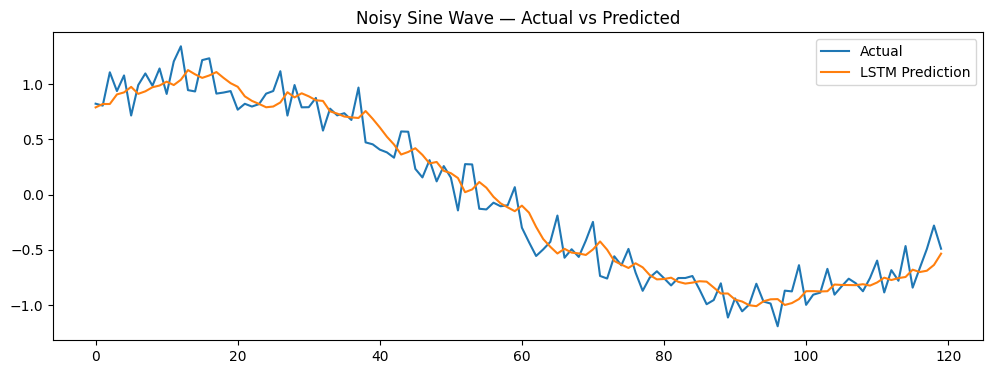

In [23]:
# TODO — Task 6

noisy_series = np.sin(x_axis) + np.random.normal(
    0, 0.15, size=len(x_axis)
)

noisy_train_series = noisy_series[:split_index]
noisy_test_series = noisy_series[split_index:]

X_train_noisy, y_train_noisy = create_sequences(noisy_train_series, SEQ_LENGTH)
X_test_noisy, y_test_noisy = create_sequences(noisy_test_series, SEQ_LENGTH)

noisy_lstm = Sequential([
    keras.Input(shape=(SEQ_LENGTH, 1)),
    LSTM(32),
    Dense(1)
])

_, noisy_pred, noisy_mse, noisy_mae, noisy_time = train_and_evaluate(
    noisy_lstm,
    X_train_noisy, y_train_noisy,
    X_test_noisy, y_test_noisy
)

print(f"Noisy LSTM MSE: {noisy_mse:.6f}")
print(f"Noisy LSTM MAE: {noisy_mae:.6f}")

plt.figure(figsize=(12, 4))
plt.plot(y_test_noisy[:120], label="Actual")
plt.plot(noisy_pred[:120], label="LSTM Prediction")
plt.title("Noisy Sine Wave — Actual vs Predicted")
plt.legend()
plt.show()


### Reflection

Noise raised test MSE from `0.000028` (clean LSTM baseline) to `0.027051` — roughly a 1,000x jump — and MAE from `0.0042` to `0.1312`. Once the sliding window contains random noise instead of a clean deterministic pattern, the model can no longer infer the next value exactly; it learns to predict something close to the underlying smooth sine curve and effectively averages out the noise, so its predictions visibly lag/smooth the noisy actual values in the plot. The achievable error is now bounded below by the injected noise variance itself (`0.15**2 = 0.0225`), not by model capacity — no amount of extra units or training fixes that floor.


## Bonus Task — Multiple Features

Create two features:

```python
feature_1 = np.sin(x_axis)
feature_2 = np.cos(x_axis)
```

Use both features to predict the next sine value.

Your input shape should become:

**(samples, timesteps, 2)**

### Questions

1. Why is the final dimension now `2`?
2. What must change in `input_shape`?
3. Does the whole model architecture need to change?


In [24]:
# TODO — Bonus Task

feature_1 = np.sin(x_axis)
feature_2 = np.cos(x_axis)

bonus_series = np.stack([feature_1, feature_2], axis=1)

bonus_train_series = bonus_series[:split_index]
bonus_test_series = bonus_series[split_index:]

def create_sequences_multi(data, seq_length=10):
    X, y = [], []

    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length, 0])

    X = np.array(X)
    y = np.array(y)

    return X, y

X_train_bonus, y_train_bonus = create_sequences_multi(bonus_train_series, SEQ_LENGTH)
X_test_bonus, y_test_bonus = create_sequences_multi(bonus_test_series, SEQ_LENGTH)

print("X_train_bonus:", X_train_bonus.shape)
print("y_train_bonus:", y_train_bonus.shape)

bonus_model = Sequential([
    keras.Input(shape=(SEQ_LENGTH, 2)),
    LSTM(32),
    Dense(1)
])

_, bonus_pred, bonus_mse, bonus_mae, bonus_time = train_and_evaluate(
    bonus_model,
    X_train_bonus, y_train_bonus,
    X_test_bonus, y_test_bonus
)

print(f"Bonus LSTM MSE: {bonus_mse:.6f}")
print(f"Bonus LSTM MAE: {bonus_mae:.6f}")


X_train_bonus: (790, 10, 2)
y_train_bonus: (790,)


Bonus LSTM MSE: 0.000001
Bonus LSTM MAE: 0.000928


### Questions

1. The final dimension is now `2` because each timestep carries two parallel readings — `sin(x)` and `cos(x)` — instead of one.
2. `keras.Input(shape=...)` (and the sliding-window reshape) must change from `(SEQ_LENGTH, 1)` to `(SEQ_LENGTH, 2)`.
3. No. `LSTM` and `Dense` already operate over an arbitrary feature dimension, so only the input shape changes — the rest of the architecture is untouched. In this run it even helped: test MSE fell to `0.000001`, lower than the single-feature LSTM baseline (`0.000028`), because `cos(x)` supplies phase/derivative information that makes predicting `sin(x)` easier.


# Self-Check Questions

1. Why does a Dense network not naturally remember previous timesteps?
2. What is the role of the hidden state in an RNN?
3. What is the main limitation of a basic RNN on long sequences?
4. How does LSTM improve memory control?
5. What is the difference between cell state and hidden state?
6. Why is GRU considered simpler than LSTM?
7. What does `return_sequences=True` do?
8. Explain `(samples, timesteps, features)`.
9. What is the purpose of a sliding window?
10. Why should chronological sequence data not be randomly shuffled before splitting?


### Answers

1. A Dense layer applies the same fixed weight matrix independently to whatever single input vector it receives. It has no internal state connecting one call to the next, so nothing carries information from one timestep to another unless that history is explicitly stacked into the input.
2. The hidden state is the RNN's running memory — a summary of everything seen in the sequence so far. It gets updated at every timestep and passed forward, letting the next prediction depend on prior context instead of only the current input.
3. Vanishing (or exploding) gradients. The same weight matrix is applied repeatedly through backpropagation-through-time, so the gradient signal from early timesteps shrinks toward zero (or blows up) over long sequences, making long-range dependencies hard to learn.
4. LSTM adds a separate cell state plus forget, input, and output gates that learn what to discard, what to add, and what to expose at each step, letting relevant information flow across many timesteps largely unchanged instead of being repeatedly transformed.
5. The cell state is the long-term memory highway, updated mostly additively through the gates and preserved across timesteps. The hidden state is the short-term, filtered output at each timestep, derived from the cell state via the output gate and exposed to the next layer/timestep.
6. GRU merges the cell state and hidden state into a single state vector and uses only two gates (update and reset) instead of LSTM's three gates plus separate cell state, so it has fewer parameters and a simpler per-step computation.
7. It makes the recurrent layer output its hidden state at every timestep (a full 3D sequence) instead of only the final timestep (a 2D vector) — required when stacking another recurrent layer on top, or when a prediction per timestep is needed.
8. `samples` = number of independent sequences in the batch; `timesteps` = how many time steps each sequence spans; `features` = how many values are recorded at each single timestep.
9. A sliding window converts one long ordered sequence into many fixed-length `(input, target)` pairs by sliding a fixed-size window across the data, turning a raw sequence into a supervised-learning dataset.
10. Shuffling before the split would let the model train on windows that overlap with or fall after the test period, leaking future information into training and making evaluation unrealistically optimistic. Real forecasting only ever has access to the past, so the split must preserve time order.


## Key Takeaways

- Sequence models are designed for data where **order matters**.
- RNN carries information using a **hidden state**.
- LSTM improves long-term memory using **gates and cell state**.
- GRU is a simpler gated recurrent architecture.
- Keras sequence models expect **3D input**:
  **samples × timesteps × features**
- Sliding windows convert a raw sequence into supervised learning samples.
